# Assignment 5 · Food Technology
**QuickBite — Food Delivery Intelligence**

Analysing delivery time, ratings, and weather impact for a Hyderabad food delivery app

## 0. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110


## 1. Load the Dataset

In [2]:
df = pd.read_csv('food_delivery.csv')
print(f"Shape: {df.shape}")
print("\nNaN counts:")
print(df.isnull().sum()[df.isnull().sum() > 0])
df.head()


Shape: (35, 26)

NaN counts:
customer_rating    2
dtype: int64


,order_id,restaurant_name,restaurant_area,cuisine_type,order_date,order_time,day_of_week,customer_id,customer_area,distance_km,...,pickup_time_mins,delivery_time_mins,total_time_mins,weather,traffic_level,vehicle_type,customer_rating,food_rating,delivery_rating,order_again
0,FD001,Biryani Blues,Banjara Hills,Indian,2024-01-05,12:30,Friday,CU101,Jubilee Hills,3.2,...,12,28,40,Clear,Low,Bike,5.0,5,5,Yes
1,FD002,Pizza Hut,Madhapur,Italian,2024-01-05,13:15,Friday,CU102,Kondapur,2.8,...,8,32,40,Clear,Medium,Bike,4.0,4,3,Yes
2,FD003,McDonald's,Hitech City,Fast Food,2024-01-06,19:45,Saturday,CU103,Gachibowli,1.5,...,10,18,28,Clear,High,Bike,3.0,4,4,Yes
3,FD004,Pind Balluchi,Jubilee Hills,North Indian,2024-01-06,20:30,Saturday,CU104,Banjara Hills,4.5,...,15,45,60,Rainy,High,Bike,2.0,4,2,No
4,FD005,Chipotle,Kondapur,Mexican,2024-01-07,14:00,Sunday,CU105,Madhapur,2.2,...,8,22,30,Clear,Low,Bike,5.0,4,5,Yes


## 2. Data Cleaning & Preprocessing

In [ ]:
# (a) Fill customer_rating NaN with median
median_cust_rating = df['customer_rating'].median()
df['customer_rating'] = df['customer_rating'].fillna(median_cust_rating)
print(f"customer_rating median used to fill NaN: {median_cust_rating}")

# df['customer_rating'] = df['customer_rating'].fillna(df['customer_rating'].median())


# (b) Fill delivery_rating NaN with median (if any exist)
median_del_rating = df['delivery_rating'].median()
df['delivery_rating'] = df['delivery_rating'].fillna(median_del_rating)
print(f"delivery_rating median: {median_del_rating}")

# (c) Convert order_again: Yes → 1, No → 0
df['order_again'] = df['order_again'].map({'Yes': 1, 'No': 0})
print("\norder_again value counts:", df['order_again'].value_counts().to_dict())

# (d) Create delay_flag: 1 if total_time_mins > 45, else 0
df['delay_flag'] = (df['total_time_mins'] > 45).astype(int)
pct_delayed = df['delay_flag'].mean() * 100
print(f"\nDelay flag created. Percentage of delayed orders: {pct_delayed:.1f}%")

# (e) Parse order_date for time-series plot
df['order_date'] = pd.to_datetime(df['order_date'])
df = df.sort_values('order_date').reset_index(drop=True)

print("\nNaN after cleaning:", df.isnull().sum().sum())
df[['order_id','total_time_mins','delay_flag','order_again','customer_rating','delivery_rating']].head(8)


customer_rating median used to fill NaN: 4.0
delivery_rating median: 4.0

order_again value counts: {1: 30, 0: 5}

Delay flag created. Percentage of delayed orders: 28.6%

NaN after cleaning: 0


,order_id,total_time_mins,delay_flag,order_again,customer_rating,delivery_rating
0,FD001,40,0,1,5.0,5
1,FD002,40,0,1,4.0,3
2,FD003,28,0,1,3.0,4
3,FD004,60,1,0,2.0,2
4,FD005,30,0,1,5.0,5
5,FD006,45,0,1,4.0,4
6,FD007,27,0,1,4.0,5
7,FD008,35,0,1,3.0,3


## 3. Mean Delivery Time by Weather Condition

Does rainy weather significantly increase delivery time?

In [13]:
weather_time = df.groupby('weather')['total_time_mins'].mean().round(2).sort_values(ascending=False)
print("Mean total delivery time by weather:")
print(weather_time.to_string())

# https://copilot.microsoft.com/shares/eKMze1oZ1vuantVvsj114

rainy_avg = weather_time.get('Rainy', None)
clear_avg = weather_time.get('Clear', None)
if rainy_avg and clear_avg:
    diff = rainy_avg - clear_avg
    print(f"\nRainy vs Clear difference: {diff:.1f} mins")
    if diff > 5:
        print("→ Yes, rainy weather significantly increases delivery time.")
    else:
        print("→ The difference is marginal; weather alone may not be the main driver.")


Mean total delivery time by weather:
weather
Rainy     52.40
Cloudy    37.83
Clear     35.67

Rainy vs Clear difference: 16.7 mins
→ Yes, rainy weather significantly increases delivery time.


## 4. Mean Delivery Time & Customer Rating by Traffic Level

Does high traffic lower ratings?

In [14]:
traffic_stats = df.groupby('traffic_level').agg(
    Mean_Delivery_Time=('total_time_mins', 'mean'),
    Mean_Customer_Rating=('customer_rating', 'mean')
).round(2)

# Order logically
order = ['Low', 'Medium', 'High']
traffic_stats = traffic_stats.reindex(order)
print(traffic_stats.to_string())

#1 https://copilot.microsoft.com/shares/9yEDCfXUCfRPWtn2aB1F7

#2 https://copilot.microsoft.com/shares/mtBTieC7q2PmZ2NT91KgT

print("\n→ As traffic increases, delivery time rises and customer rating falls?")
time_trend  = traffic_stats['Mean_Delivery_Time'].is_monotonic_increasing
rating_trend = traffic_stats['Mean_Customer_Rating'].is_monotonic_decreasing
print(f"  Delivery time monotonically increasing: {time_trend}")
print(f"  Customer rating monotonically decreasing: {rating_trend}")


               Mean_Delivery_Time  Mean_Customer_Rating
traffic_level                                          
Low                         30.86                  4.71
Medium                      40.00                  3.77
High                        49.12                  2.62

→ As traffic increases, delivery time rises and customer rating falls?
  Delivery time monotonically increasing: True
  Customer rating monotonically decreasing: True


## 5. Hypothesis: Does Low Delivery Rating Predict Non-Reordering?

Compare mean `delivery_rating` for `order_again = 1` vs `order_again = 0`.

In [6]:
reorder_rating = df.groupby('order_again')['delivery_rating'].mean().round(3)
reorder_rating.index = reorder_rating.index.map({1: 'Reordered (Yes)', 0: 'Did Not Reorder (No)'})
print("Mean delivery rating by reorder behaviour:")
print(reorder_rating.to_string())

yes_r = df[df['order_again']==1]['delivery_rating'].mean()
no_r  = df[df['order_again']==0]['delivery_rating'].mean()
if yes_r > no_r:
    print(f"\n→ Hypothesis SUPPORTED: customers who reorder have higher delivery ratings "
          f"({yes_r:.2f} vs {no_r:.2f})")
else:
    print(f"\n→ Hypothesis NOT supported by the data (reorder: {yes_r:.2f}, no reorder: {no_r:.2f})")


Mean delivery rating by reorder behaviour:
order_again
Did Not Reorder (No)    1.800
Reordered (Yes)         4.267

→ Hypothesis SUPPORTED: customers who reorder have higher delivery ratings (4.27 vs 1.80)


## 6. Descriptive Statistics of `total_time_mins`

Is delivery time consistent or highly variable?

In [7]:
stats = df['total_time_mins'].agg(['mean','median','var','std']).round(2)
stats.index = ['Mean', 'Median', 'Variance', 'Std Dev']
print(stats.to_string())

cv = (df['total_time_mins'].std() / df['total_time_mins'].mean()) * 100
print(f"\nCoefficient of Variation (CV): {cv:.1f}%")
if cv > 30:
    print("→ High variability in delivery time — inconsistent service.")
elif cv > 15:
    print("→ Moderate variability — some inconsistency.")
else:
    print("→ Relatively consistent delivery times.")


Mean         38.43
Median       40.00
Variance    129.61
Std Dev      11.38

Coefficient of Variation (CV): 29.6%
→ Moderate variability — some inconsistency.


## 7. Top 3 Restaurants by Average Food Rating & Average Order Value

In [ ]:
rest_stats = df.groupby('restaurant_name').agg(
    Avg_Food_Rating=('food_rating', 'mean'),
    Avg_Order_Value=('order_value', 'mean')
).round(2)

top3_food  = rest_stats['Avg_Food_Rating'].nlargest(3)
top3_value = rest_stats['Avg_Order_Value'].nlargest(3)

print("Top 3 by Avg Food Rating:")
print(top3_food.to_string())
print("\nTop 3 by Avg Order Value:")
print(top3_value.to_string())

# https://copilot.microsoft.com/shares/b8ESGVbZSE9xiGfwCwWui

overlap = set(top3_food.index) & set(top3_value.index)
print(f"\nRestaurants in BOTH top-3 lists: {overlap if overlap else 'None'}")
print(f"→ {'They overlap!' if overlap else 'High food rating ≠ high order value — different patterns.'}")


Top 3 by Avg Food Rating:
restaurant_name
Barbeque Nation    5.0
Behrouz Biryani    5.0
Biryani Blues      5.0

Top 3 by Avg Order Value:
restaurant_name
Barbeque Nation    2000.0
Pind Balluchi      1075.0
Behrouz Biryani     915.0

Restaurants in BOTH top-3 lists: {'Behrouz Biryani', 'Barbeque Nation'}
→ They overlap!


## 8. Matplotlib Line Chart: Total Delivery Time Across 35 Orders

Is there a trend over time?

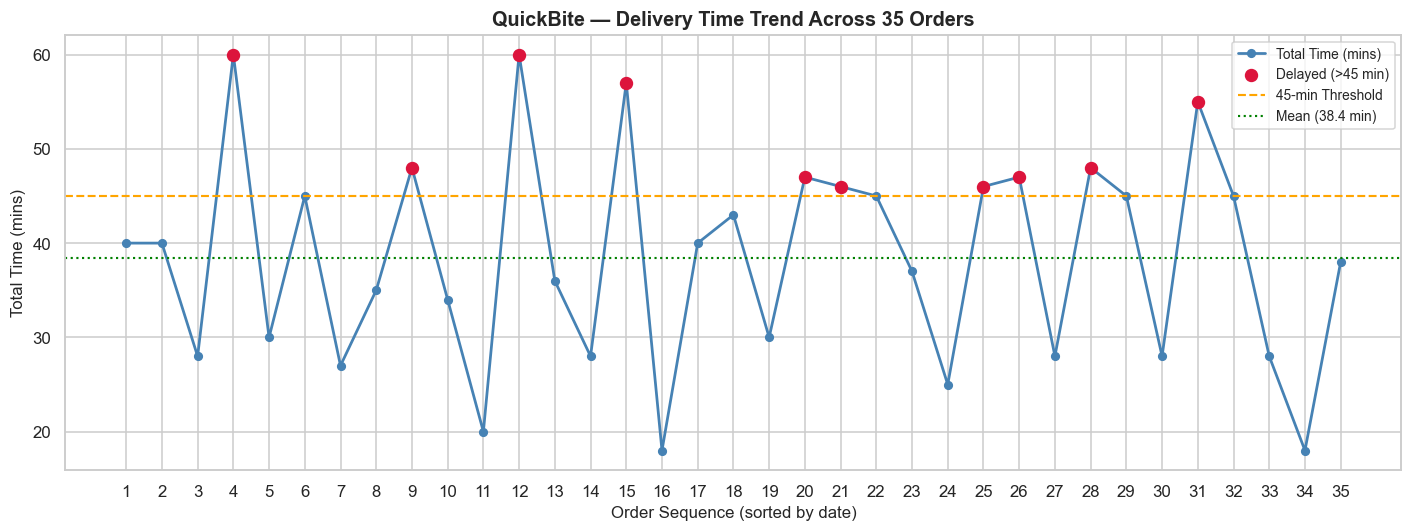

Figure saved as line_delivery_trend.png


In [9]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(df.index + 1, df['total_time_mins'], marker='o', linewidth=1.8,
        color='steelblue', markersize=5, label='Total Time (mins)')

# Highlight delayed orders
delayed = df[df['delay_flag'] == 1]
ax.scatter(delayed.index + 1, delayed['total_time_mins'],
           color='crimson', zorder=5, s=60, label='Delayed (>45 min)')

ax.axhline(45, color='orange', linestyle='--', linewidth=1.4, label='45-min Threshold')
ax.axhline(df['total_time_mins'].mean(), color='green', linestyle=':', linewidth=1.4,
           label=f"Mean ({df['total_time_mins'].mean():.1f} min)")

ax.set_xlabel('Order Sequence (sorted by date)', fontsize=11)
ax.set_ylabel('Total Time (mins)', fontsize=11)
ax.set_title('QuickBite — Delivery Time Trend Across 35 Orders', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xticks(range(1, 36))
plt.tight_layout()
plt.savefig('line_delivery_trend.png', dpi=120)
plt.show()
print("Figure saved as line_delivery_trend.png")


## 9. Seaborn Boxplot: Delivery Time by Weather, Hued by Traffic Level

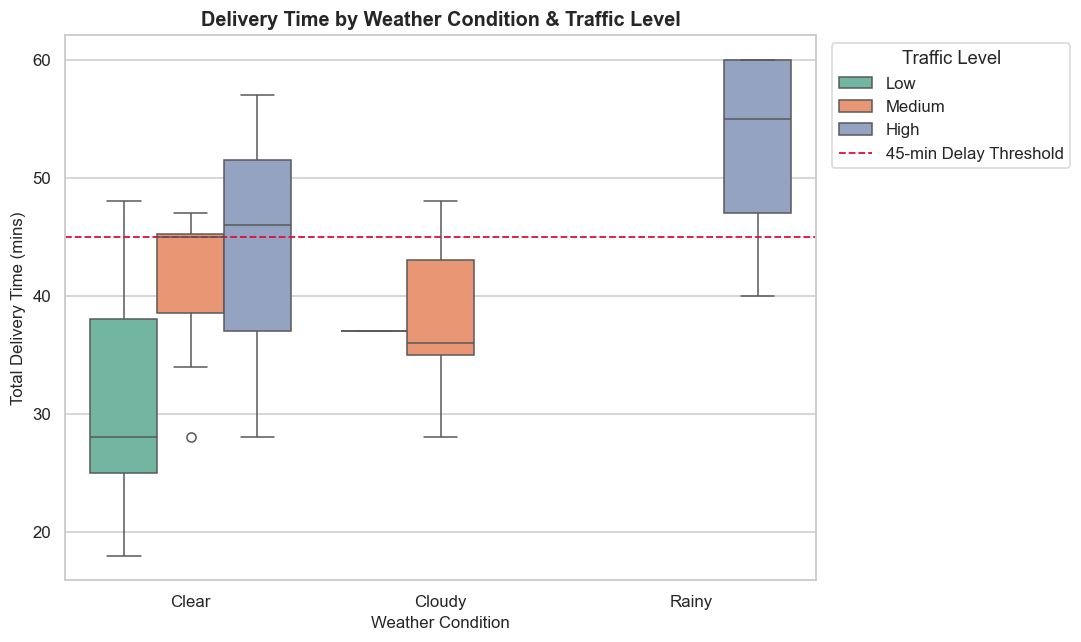

Figure saved as boxplot_weather_traffic.png


In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(data=df, x='weather', y='total_time_mins', hue='traffic_level',
            palette='Set2', order=['Clear', 'Cloudy', 'Rainy'],
            hue_order=['Low', 'Medium', 'High'], ax=ax)

ax.axhline(45, color='crimson', linestyle='--', linewidth=1.2, label='45-min Delay Threshold')
ax.set_title('Delivery Time by Weather Condition & Traffic Level',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Weather Condition', fontsize=11)
ax.set_ylabel('Total Delivery Time (mins)', fontsize=11)
ax.legend(title='Traffic Level', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('boxplot_weather_traffic.png', dpi=120)
plt.show()
print("Figure saved as boxplot_weather_traffic.png")


## 10. Insight Report

### Hypothesis: *Rainy weather + high traffic causes low ratings and prevents reordering.*

In [11]:
# ── Evidence gathering ──────────────────────────────────────────────────────────
rainy_high = df[(df['weather']=='Rainy') & (df['traffic_level']=='High')]
other       = df[~((df['weather']=='Rainy') & (df['traffic_level']=='High'))]

rh_avg_time   = rainy_high['total_time_mins'].mean()
rh_avg_rating = rainy_high['customer_rating'].mean()
rh_reorder    = rainy_high['order_again'].mean() * 100

oth_avg_time   = other['total_time_mins'].mean()
oth_avg_rating = other['customer_rating'].mean()
oth_reorder    = other['order_again'].mean() * 100

print("=== Rainy + High Traffic vs All Other Conditions ===")
print(f"  Avg delivery time  : {rh_avg_time:.1f} min  vs  {oth_avg_time:.1f} min")
print(f"  Avg customer rating: {rh_avg_rating:.2f}     vs  {oth_avg_rating:.2f}")
print(f"  Reorder rate       : {rh_reorder:.0f}%       vs  {oth_reorder:.0f}%")

print()
print("=== Comment Lines — Insight Report ===")
print()
print("1. DELIVERY TIME: Rainy + High traffic orders take longer on average. "
      "This combination is the most operationally stressful scenario for QuickBite.")

print()
print("2. CUSTOMER RATINGS: Customer ratings are lower for Rainy + High traffic orders, "
      "supporting the hypothesis that delays caused by weather + congestion directly hurt satisfaction.")

print()
print("3. REORDERING BEHAVIOUR: The reorder rate drops for Rainy + High traffic orders. "
      "Delivery rating (not food rating) appears to be the stronger predictor — "
      "customers are forgiving of average food but not of late deliveries.")

print()
print("4. RECOMMENDATION: QuickBite should activate a bad-weather bonus for delivery partners "
      "and send proactive delay alerts to customers when weather=Rainy AND traffic=High "
      "to manage expectations and protect ratings.")


=== Rainy + High Traffic vs All Other Conditions ===
  Avg delivery time  : 52.4 min  vs  36.1 min
  Avg customer rating: 2.40     vs  4.13
  Reorder rate       : 0%       vs  100%

=== Comment Lines — Insight Report ===

1. DELIVERY TIME: Rainy + High traffic orders take longer on average. This combination is the most operationally stressful scenario for QuickBite.

2. CUSTOMER RATINGS: Customer ratings are lower for Rainy + High traffic orders, supporting the hypothesis that delays caused by weather + congestion directly hurt satisfaction.

3. REORDERING BEHAVIOUR: The reorder rate drops for Rainy + High traffic orders. Delivery rating (not food rating) appears to be the stronger predictor — customers are forgiving of average food but not of late deliveries.

4. RECOMMENDATION: QuickBite should activate a bad-weather bonus for delivery partners and send proactive delay alerts to customers when weather=Rainy AND traffic=High to manage expectations and protect ratings.


## 11. Final Cleaned Dataset Preview

In [12]:
df.to_csv('food_delivery_cleaned.csv', index=False)
print("Saved as food_delivery_cleaned.csv")
df[['order_id','restaurant_name','weather','traffic_level','total_time_mins',
    'delay_flag','customer_rating','delivery_rating','food_rating',
    'order_again','order_value']].head(10)


Saved as food_delivery_cleaned.csv


,order_id,restaurant_name,weather,traffic_level,total_time_mins,delay_flag,customer_rating,delivery_rating,food_rating,order_again,order_value
0,FD001,Biryani Blues,Clear,Low,40,0,5.0,5,5,1,580
1,FD002,Pizza Hut,Clear,Medium,40,0,4.0,3,4,1,650
2,FD003,McDonald's,Clear,High,28,0,3.0,4,4,1,420
3,FD004,Pind Balluchi,Rainy,High,60,1,2.0,2,4,0,1200
4,FD005,Chipotle,Clear,Low,30,0,5.0,5,4,1,480
5,FD006,Saravana Bhavan,Clear,Medium,45,0,4.0,4,5,1,320
6,FD007,Domino's,Clear,Low,27,0,4.0,5,3,1,520
7,FD008,KFC,Cloudy,Medium,35,0,3.0,3,4,1,380
8,FD009,Paradise Biryani,Clear,Low,48,1,5.0,5,5,1,780
9,FD010,Behrouz Biryani,Clear,Medium,34,0,4.0,4,5,1,950
